# Project 2

# Numerical Solution of Modified Shock Equations

**Course:** Supernova Remnants

**Author:** Israt Sultana Eithu

**Faculty:** Faculty of Mathematics, University of Belgrade

## Problem Statement

This notebook presents the numerical solution of the modified shock equations
for a cosmic-ray modified supernova remnant.

The original assignment instructions are provided in:

**Project2_Instructions.pdf**

### Objectives

- Solve the dimensionless Euler equations numerically.
- Compute the modified shock structure.
- Determine the total compression ratio.
- Calculate the similarity parameter **B**.
- Compute the fractions of kinetic, gas internal, and cosmic-ray internal energy.
- Reproduce the dimensionless profiles of **F**, **G**, **H**, and **U**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
beta = 0.5

gamma_g = 5.0/3.0
gamma_cr = 4.0/3.0

gamma = (5 + 3*(1-beta))/(3*(2-beta))

R = (gamma + 1)/(gamma - 1)

print("gamma =", gamma)
print("Compression ratio =", R)

gamma = 1.4444444444444444
Compression ratio = 5.500000000000001


In [3]:
A = (gamma + 1)/2

print(A)

1.2222222222222223


In [4]:
def denominator(xi, F, U):

    term1 = (gamma - 1)**2 * (
        beta*gamma_g*F**(gamma_g-2)
        + (1-beta)*gamma_cr*F**(gamma_cr-2)
    )

    term2 = 4*xi**2*(U - A*xi)**3

    return term1 + term2

In [5]:
def dU_dxi(xi, F, U):

    D = denominator(xi, F, U)

    num1 = (gamma - 1)**2 * (
        beta*F**(gamma_g-2)*(1.5*(gamma+1)*xi - 2*gamma_g*U)
        +
        (1-beta)*F**(gamma_cr-2)*(1.5*(gamma+1)*xi - 2*gamma_cr*U)
    )

    num2 = (
        3*(gamma+1)*xi**3*U*(U - A*xi)**2
    )

    return (1/xi)*(num1/D + num2/D)

In [6]:
def dF_dxi(xi, F, U):

    D = denominator(xi, F, U)

    part1 = (
        1.5*(gamma+1)*(gamma-1)**2 *
        (
            beta*F**(gamma_g-2)
            +
            (1-beta)*F**(gamma_cr-2)
        )
    )

    part2 = (
        xi*U*(8*U - (gamma+1)*xi)*(U - A*xi)**2
    )

    bracket = part1/D + part2/D

    return -F/(U - A*xi)*bracket

In [7]:
def f(xi, y):
    return system(xi, y)

In [8]:
def system(xi, y):

    F = y[0]
    U = y[1]

    return np.array([
        dF_dxi(xi, F, U),
        dU_dxi(xi, F, U)
    ])

In [9]:
sqrt21 = np.sqrt(21.0)

In [10]:
def rk6_step(x, y, h):

    k1 = h*f(x, y)

    k2 = h*f(
        x + h,
        y + k1
    )

    k3 = h*f(
        x + h/2,
        y + (3*k1 + k2)/8
    )

    k4 = h*f(
        x + 2*h/3,
        y + (8*k1 + 2*k2 + 8*k3)/27
    )

    k5 = h*f(
        x + (7 - sqrt21)*h/14,
        y + (
            3*(3*sqrt21 - 7)*k1
            - 8*(7 - sqrt21)*k2
            + 48*(7 - sqrt21)*k3
            - 3*(21 - sqrt21)*k4
        )/392
    )

    k6 = h*f(
        x + (7 + sqrt21)*h/14,
        y + (
            -5*(231 + 51*sqrt21)*k1
            -40*(7 + sqrt21)*k2
            -320*sqrt21*k3
            +3*(21 + 121*sqrt21)*k4
            +392*(6 + sqrt21)*k5
        )/1960
    )

    k7 = h*f(
        x + h,
        y + (
            15*(22 + 7*sqrt21)*k1
            +120*k2
            +40*(7*sqrt21 - 5)*k3
            -63*(3*sqrt21 - 2)*k4
            -14*(49 + 9*sqrt21)*k5
            +70*(7 - sqrt21)*k6
        )/180
    )

    y_next = y + (
        9*k1
        +64*k3
        +49*k5
        +49*k6
        +9*k7
    )/180

    return y_next

In [11]:
h = -1e-4

xi_values = [1.0]

F_values = [1.0]

U_values = [1.0]

y = np.array([1.0, 1.0])

xi = 1.0

In [12]:
while xi > 0.01:

    y = rk6_step(xi, y, h)

    xi += h

    xi_values.append(xi)

    F_values.append(y[0])

    U_values.append(y[1])

In [13]:
G_values = []

H_values = []

for xi, F, U in zip(xi_values, F_values, U_values):

    rhs = (1 - gamma)/(2*xi**3)

    factor = (U/xi - (gamma+1)/2)

    G = rhs / (F**(1-gamma_g) * factor)

    H = rhs / (F**(1-gamma_cr) * factor)

    G_values.append(G)

    H_values.append(H)

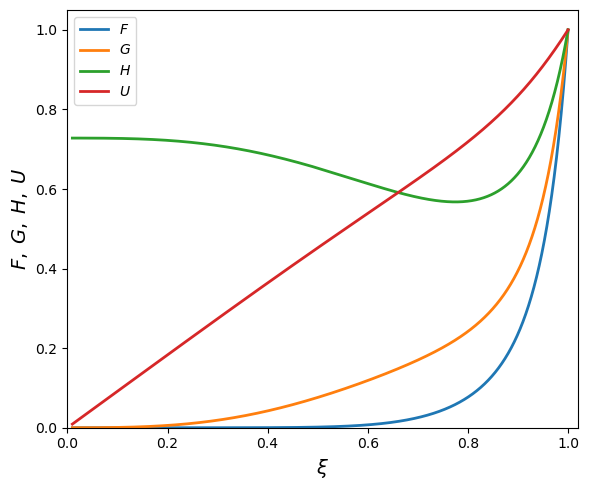

In [14]:
plt.figure(figsize=(6,5))

plt.plot(xi_values, F_values, lw=2, label=r'$F$')
plt.plot(xi_values, G_values, lw=2, label=r'$G$')
plt.plot(xi_values, H_values, lw=2, label=r'$H$')
plt.plot(xi_values, U_values, lw=2, label=r'$U$')

plt.xlabel(r'$\xi$', fontsize=14)
plt.ylabel(r'$F,\;G,\;H,\;U$', fontsize=14)

plt.xlim(0,1.02)
plt.ylim(0,1.05)

plt.legend(frameon=True)

plt.tight_layout()

plt.savefig(
    "FGHU_profiles.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "FGHU_profiles.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig("FGHU_profiles", dpi=300, bbox_inches='tight')
plt.show()



In [15]:
xi_values = np.array(xi_values)

F_values = np.array(F_values)

G_values = np.array(G_values)

H_values = np.array(H_values)

U_values = np.array(U_values)

In [16]:
integrand = (
    (1/(gamma-1))*F_values*U_values**2
    +
    (beta/(gamma_g-1))*G_values
    +
    ((1-beta)/(gamma_cr-1))*H_values
)

integrand *= xi_values**2

In [17]:
I = np.trapezoid(integrand, xi_values)

print(I)

-0.5137313793942178


In [18]:
I = abs(I)

print("I =", I)

I = 0.5137313793942178


In [19]:
B_minus5 = (
    32*np.pi
    /
    (25*(gamma+1))
) * I

B = (1/B_minus5)**(1/5)

print("B =", B)

B = 1.034229323224387


In [20]:
print("gamma =", gamma)
print("R =", R)
print("B =", B)

gamma = 1.4444444444444444
R = 5.500000000000001
B = 1.034229323224387


In [21]:
kinetic_integrand = (
    (1/(gamma-1))
    *F_values
    *U_values**2
    *xi_values**2
)

In [22]:
gas_integrand = (
    (beta/(gamma_g-1))
    *G_values
    *xi_values**2
)

In [23]:
cr_integrand = (
    ((1-beta)/(gamma_cr-1))
    *H_values
    *xi_values**2
)

In [24]:
T = abs(np.trapezoid(kinetic_integrand, xi_values))

Ug = abs(np.trapezoid(gas_integrand, xi_values))

Ucr = abs(np.trapezoid(cr_integrand, xi_values))

print(T)
print(Ug)
print(Ucr)

0.10997106672784177
0.07587385369204984
0.32788645897432617


In [25]:
total = T + Ug + Ucr

T_frac = T/total

Ug_frac = Ug/total

Ucr_frac = Ucr/total

print("T/E =", T_frac)

print("Ug/E =", Ug_frac)

print("Ucr/E =", Ucr_frac)

T/E = 0.21406336295345157
Ug/E = 0.147691686230105
Ucr/E = 0.6382449508164435


In [26]:
print("Kinetic Energy (%) =", 100*T_frac)

print("Gas Energy (%) =", 100*Ug_frac)

print("Cosmic-Ray Energy (%) =", 100*Ucr_frac)

Kinetic Energy (%) = 21.406336295345156
Gas Energy (%) = 14.7691686230105
Cosmic-Ray Energy (%) = 63.82449508164435
